# Week 4 – Day 4: Model Comparison and Prediction Analysis

## Objective

Perform a professional comparison of XGBoost, Baseline GNN, and Attention GNN using the same held-out test properties.

The analysis will evaluate RMSE, MAPE, MAE and R², analyze prediction errors and price-range performance, identify the best-performing model, and prepare a dashboard-ready prediction dataset.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pathlib import Path

from xgboost import XGBRegressor

from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score,mean_absolute_percentage_error)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [3]:
BASE_DIR = Path("..")

DATA_DIR = (BASE_DIR / "data" / "processed")

WEEK2_DIR = DATA_DIR / "week-2"
WEEK3_DIR = DATA_DIR / "week-3"
GNN_DIR = WEEK3_DIR / "gnn"

OUTPUT_DIR = GNN_DIR / "day4"
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

VIS_DIR = (BASE_DIR / "reports" / "week-4" / "visualizations")

VIS_DIR.mkdir(parents=True,exist_ok=True)

print("Output directory:")
print(OUTPUT_DIR.resolve())

Output directory:
E:\AARAV\Infotact-DS-ML\Project-3-Geospatial-Valuation\data\processed\week-3\gnn\day4


In [4]:
required_files = [
    WEEK3_DIR / "final_graph_nodes.csv",
    WEEK3_DIR / "final_graph_targets.csv",
    GNN_DIR / "baseline_gnn_predictions.csv",
    GNN_DIR / "attention_gnn_predictions.csv",
    WEEK3_DIR / "gnn" / "housing_graph_data.pt"
]

for file_path in required_files:
    print(f"{file_path.name}:", file_path.exists())

assert all(file_path.exists() for file_path in required_files)

print("✅ All required input files found.")

final_graph_nodes.csv: True
final_graph_targets.csv: True
baseline_gnn_predictions.csv: True
attention_gnn_predictions.csv: True
housing_graph_data.pt: True
✅ All required input files found.


In [5]:
nodes_df = pd.read_csv(WEEK3_DIR / "final_graph_nodes.csv")

targets_df = pd.read_csv(WEEK3_DIR / "final_graph_targets.csv")

print("nodes_df shape:", nodes_df.shape)
print("targets_df shape:", targets_df.shape)

nodes_df shape: (21613, 26)
targets_df shape: (21613, 2)


In [6]:
baseline_gnn_df = pd.read_csv(GNN_DIR / "baseline_gnn_predictions.csv")

attention_gnn_df = pd.read_csv(GNN_DIR / "attention_gnn_predictions.csv")

print("Baseline GNN:", baseline_gnn_df.shape)

print("Attention GNN:", attention_gnn_df.shape)

Baseline GNN: (21613, 5)
Attention GNN: (21613, 5)


In [7]:
graph_data = torch.load(GNN_DIR / "housing_graph_data.pt",weights_only=False)

print(graph_data)

Data(x=[21613, 24], edge_index=[2, 108065], y=[21613, 1], train_mask=[21613], val_mask=[21613], test_mask=[21613])


In [8]:
nodes_df = (nodes_df.sort_values("node_id").reset_index(drop=True))

targets_df = (targets_df.sort_values("node_id").reset_index(drop=True))

assert len(nodes_df) == graph_data.num_nodes
assert len(targets_df) == graph_data.num_nodes

print("✅ Node and target ordering validated.")

✅ Node and target ordering validated.


In [9]:
FEATURE_COLUMNS = [col for col in nodes_df.columns if col not in ["node_id", "id"]]

assert len(FEATURE_COLUMNS) == 24

print("Number of model features:", len(FEATURE_COLUMNS))
print("\nFeatures:")
for feature in FEATURE_COLUMNS:
    print("-", feature)

Number of model features: 24

Features:
- bedrooms
- bathrooms
- sqft_living
- sqft_lot
- floors
- waterfront
- view
- condition
- grade
- sqft_above
- sqft_basement
- House Age
- yr_built
- yr_renovated
- lat
- long
- lat_scaled
- long_scaled
- mean_neighbor_distance_scaled
- median_neighbor_distance_scaled
- min_neighbor_distance_scaled
- max_neighbor_distance_scaled
- std_neighbor_distance_scaled
- neighbor_count


In [10]:
X = nodes_df[FEATURE_COLUMNS].copy()

y = targets_df["price"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

assert X.shape == (21613, 24)
assert len(y) == 21613

print("✅ Feature and target datasets prepared.")

X shape: (21613, 24)
y shape: (21613,)
✅ Feature and target datasets prepared.


In [11]:
train_indices = (graph_data.train_mask.cpu().numpy().nonzero()[0])

val_indices = (graph_data.val_mask.cpu().numpy().nonzero()[0])

test_indices = (graph_data.test_mask.cpu().numpy().nonzero()[0])

print("Training:", len(train_indices))
print("Validation:", len(val_indices))
print("Test:", len(test_indices))

assert len(train_indices) == 15129
assert len(val_indices) == 3242
assert len(test_indices) == 3242

print("✅ Exact GNN train/validation/test split loaded.")

Training: 15129
Validation: 3242
Test: 3242
✅ Exact GNN train/validation/test split loaded.


In [12]:
num_nodes = len(X)

split_df = pd.DataFrame({
    "node_id": np.arange(num_nodes),
    "split": "unused"
})

split_df.loc[train_indices,"split"] = "train"

split_df.loc[val_indices,"split"] = "validation"

split_df.loc[test_indices,"split"] = "test"

assert split_df["split"].isin(["train", "validation", "test"]).all()

split_df.to_csv(OUTPUT_DIR / "final_model_split.csv",index=False)

print("✅ Final model split saved.")

✅ Final model split saved.


In [13]:
baseline_gnn_test = (baseline_gnn_df.iloc[test_indices].reset_index(drop=True))

attention_gnn_test = (attention_gnn_df.iloc[test_indices].reset_index(drop=True))

y_test = (y.iloc[test_indices].reset_index(drop=True))

print("Common test properties:",len(y_test))

assert len(y_test) == 3242

Common test properties: 3242


In [14]:
assert np.allclose(baseline_gnn_test["actual_price"].to_numpy(),y_test.to_numpy())

assert np.allclose(attention_gnn_test["actual_price"].to_numpy(),y_test.to_numpy())

print("✅ GNN predictions aligned with the final test set.")

✅ GNN predictions aligned with the final test set.


In [15]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1
)

X_train = X.iloc[train_indices]
y_train = y.iloc[train_indices]

X_val = X.iloc[val_indices]
y_val = y.iloc[val_indices]

X_test = X.iloc[test_indices]
y_test = y.iloc[test_indices]

xgb_model.fit(X_train,y_train,eval_set=[(X_val, y_val)],verbose=False)

print("✅ Final comparison XGBoost trained.")

✅ Final comparison XGBoost trained.


In [16]:
xgb_test_predictions = xgb_model.predict(X_test)

assert len(xgb_test_predictions) == 3242

print("XGBoost test predictions:",len(xgb_test_predictions))

XGBoost test predictions: 3242


In [17]:
final_predictions = pd.DataFrame({
    "node_id": nodes_df.iloc[test_indices]["node_id"].to_numpy(),
    "actual_price": y_test.to_numpy(),
    "xgboost_prediction":xgb_test_predictions,
    "baseline_gnn_prediction":baseline_gnn_test["predicted_price"].to_numpy(),
    "attention_gnn_prediction":attention_gnn_test["predicted_price"].to_numpy()
})

print(final_predictions.head())

   node_id  actual_price  xgboost_prediction  baseline_gnn_prediction  \
0       10      662500.0        718556.68750                758112.90   
1       22      285000.0        309347.21875                320456.47   
2       23      252700.0        217653.15625                207033.72   
3       27      667000.0        685049.81250                671401.50   
4       33      535000.0        506988.25000                526937.56   

   attention_gnn_prediction  
0                 557375.40  
1                 321479.00  
2                 287241.88  
3                 695260.10  
4                 563047.20  


In [18]:
prediction_columns = [
    "xgboost_prediction",
    "baseline_gnn_prediction",
    "attention_gnn_prediction"
]

assert len(final_predictions) == 3242

assert final_predictions["actual_price"].notna().all()

assert np.isfinite(final_predictions[prediction_columns].to_numpy()).all()

print("✅ Final prediction table validated.")

✅ Final prediction table validated.


In [19]:
def calculate_metrics(actual,predicted):
    rmse = np.sqrt(mean_squared_error(actual,predicted))
    mae = mean_absolute_error(actual,predicted)
    mape = (mean_absolute_percentage_error(actual,predicted) * 100)
    r2 = r2_score(actual,predicted)

    return {
        "RMSE": rmse,
        "MAPE": mape,
        "MAE": mae,
        "R2": r2
    }

In [20]:
actual = final_predictions["actual_price"]
xgb_metrics = calculate_metrics(actual,final_predictions["xgboost_prediction"])
baseline_metrics = calculate_metrics(actual,final_predictions["baseline_gnn_prediction"])
attention_metrics = calculate_metrics(actual,final_predictions["attention_gnn_prediction"])

print("XGBoost:", xgb_metrics)
print("Baseline GNN:", baseline_metrics)
print("Attention GNN:", attention_metrics)

XGBoost: {'RMSE': np.float64(75232.35868141254), 'MAPE': 11.387989684931906, 'MAE': 51576.165383058295, 'R2': 0.9038456472105887}
Baseline GNN: {'RMSE': np.float64(80285.80711639297), 'MAPE': 12.317673842962758, 'MAE': 55964.85948488587, 'R2': 0.8904941934198356}
Attention GNN: {'RMSE': np.float64(121562.17260211175), 'MAPE': 19.396719437953884, 'MAE': 87503.56360888341, 'R2': 0.748952153889478}


In [21]:
model_comparison = pd.DataFrame({
    "Model": [
        "XGBoost",
        "Baseline GNN",
        "Attention GNN"
    ],
    "RMSE": [
        xgb_metrics["RMSE"],
        baseline_metrics["RMSE"],
        attention_metrics["RMSE"]
    ],
    "MAPE": [
        xgb_metrics["MAPE"],
        baseline_metrics["MAPE"],
        attention_metrics["MAPE"]
    ],
    "MAE": [
        xgb_metrics["MAE"],
        baseline_metrics["MAE"],
        attention_metrics["MAE"]
    ],
    "R2": [
        xgb_metrics["R2"],
        baseline_metrics["R2"],
        attention_metrics["R2"]
    ]
})

display(model_comparison)

,Model,RMSE,MAPE,MAE,R2
0,XGBoost,75232.358681,11.387990,51576.165383,0.903846
1,Baseline GNN,80285.807116,12.317674,55964.859485,0.890494
2,Attention GNN,121562.172602,19.396719,87503.563609,0.748952


In [22]:
xgb_rmse = xgb_metrics["RMSE"]
xgb_mape = xgb_metrics["MAPE"]

model_comparison["RMSE_Change_vs_XGBoost_%"] = ((model_comparison["RMSE"] - xgb_rmse) / xgb_rmse) * 100

model_comparison["MAPE_Change_vs_XGBoost_%"] = ((model_comparison["MAPE"] - xgb_mape) / xgb_mape) * 100

display(model_comparison)

,Model,RMSE,MAPE,MAE,R2,RMSE_Change_vs_XGBoost_%,MAPE_Change_vs_XGBoost_%
0,XGBoost,75232.358681,11.387990,51576.165383,0.903846,0.000000,0.000000
1,Baseline GNN,80285.807116,12.317674,55964.859485,0.890494,6.717121,8.163725
2,Attention GNN,121562.172602,19.396719,87503.563609,0.748952,61.582296,70.326106


In [23]:
print("Historical Week 2 XGBoost MAPE: 17.31%")

print(f"Day 4 Common-Test XGBoost MAPE: " f"{xgb_metrics['MAPE']:.2f}%")

Historical Week 2 XGBoost MAPE: 17.31%
Day 4 Common-Test XGBoost MAPE: 11.39%


In [24]:
best_model_row = (model_comparison.sort_values("MAPE").iloc[0])

best_model_name = best_model_row["Model"]

print("Best model:",best_model_name)

print(f"Best MAPE: "f"{best_model_row['MAPE']:.2f}%")

Best model: XGBoost
Best MAPE: 11.39%


In [25]:
for model_name, prediction_column in {
    "xgboost": "xgboost_prediction",
    "baseline_gnn": "baseline_gnn_prediction",
    "attention_gnn": "attention_gnn_prediction"
}.items():

    final_predictions[f"{model_name}_absolute_error"] = (final_predictions["actual_price"] - final_predictions[prediction_column]).abs()

    final_predictions[f"{model_name}_percentage_error"] = (final_predictions[f"{model_name}_absolute_error"] / final_predictions["actual_price"]) * 100

In [26]:
final_predictions["price_range"] = pd.cut(
    final_predictions["actual_price"],
    bins=[
        0,
        300000,
        500000,
        750000,
        1000000,
        np.inf
    ],
    labels=[
        "Below $300K",
        "$300K–$500K",
        "$500K–$750K",
        "$750K–$1M",
        "Above $1M"
    ]
)

price_range_analysis = (
    final_predictions
    .groupby("price_range",observed=False)
    .agg(
        property_count=("actual_price","size"),
        mean_actual_price=("actual_price","mean"),
        xgboost_mape=("xgboost_percentage_error","mean"),
        baseline_gnn_mape=("baseline_gnn_percentage_error","mean"),
        attention_gnn_mape=("attention_gnn_percentage_error","mean"
        )
    )
    .reset_index()
)

display(price_range_analysis)

,price_range,property_count,mean_actual_price,xgboost_mape,baseline_gnn_mape,attention_gnn_mape
0,Below $300K,716,2.432924e+05,16.610269,18.285038,29.612436
1,$300K–$500K,1196,3.975279e+05,10.868581,11.001991,17.376220
2,$500K–$750K,833,6.126044e+05,9.262492,10.749736,15.732417
3,$750K–$1M,313,8.586078e+05,8.929861,9.420725,15.117845
4,Above $1M,184,1.112593e+06,8.246659,9.675073,16.645177


In [27]:
model_comparison.to_csv(GNN_DIR / "final_model_comparison.csv",index=False)

print("✅ Saved: final_model_comparison.csv")

✅ Saved: final_model_comparison.csv


In [28]:
final_predictions.to_csv(GNN_DIR / "final_prediction_error_analysis.csv",index=False)

print("✅ Saved: final_prediction_error_analysis.csv")

✅ Saved: final_prediction_error_analysis.csv


In [29]:
price_range_analysis.to_csv(GNN_DIR / "final_price_range_analysis.csv",index=False)

print("✅ Saved: final_price_range_analysis.csv")

✅ Saved: final_price_range_analysis.csv


In [30]:
dashboard_predictions = final_predictions[
    [
        "node_id",
        "actual_price",
        "xgboost_prediction",
        "baseline_gnn_prediction",
        "attention_gnn_prediction"
    ]
].copy()

dashboard_predictions["selected_model"] = best_model_name

if best_model_name == "XGBoost":
    dashboard_predictions["selected_prediction"] = dashboard_predictions["xgboost_prediction"]

elif best_model_name == "Baseline GNN":
    dashboard_predictions["selected_prediction"] = dashboard_predictions["baseline_gnn_prediction"]

else:
    dashboard_predictions["selected_prediction"] = dashboard_predictions["attention_gnn_prediction"]

dashboard_predictions["prediction_error"] = (dashboard_predictions["actual_price"] - dashboard_predictions["selected_prediction"])

dashboard_predictions["absolute_error"] = (dashboard_predictions["prediction_error"]).abs()

dashboard_predictions["percentage_error"] = (dashboard_predictions["absolute_error"] / dashboard_predictions["actual_price"]) * 100

display(dashboard_predictions.head())

,node_id,actual_price,xgboost_prediction,baseline_gnn_prediction,attention_gnn_prediction,selected_model,selected_prediction,prediction_error,absolute_error,percentage_error
0,10,662500.0,718556.68750,758112.90,557375.40,XGBoost,718556.68750,-56056.68750,56056.68750,8.461387
1,22,285000.0,309347.21875,320456.47,321479.00,XGBoost,309347.21875,-24347.21875,24347.21875,8.542884
2,23,252700.0,217653.15625,207033.72,287241.88,XGBoost,217653.15625,35046.84375,35046.84375,13.868953
3,27,667000.0,685049.81250,671401.50,695260.10,XGBoost,685049.81250,-18049.81250,18049.81250,2.706119
4,33,535000.0,506988.25000,526937.56,563047.20,XGBoost,506988.25000,28011.75000,28011.75000,5.235841


In [31]:
dashboard_predictions.to_csv(GNN_DIR / "dashboard_predictions.csv",index=False)

print("✅ Saved: dashboard_predictions.csv")

✅ Saved: dashboard_predictions.csv


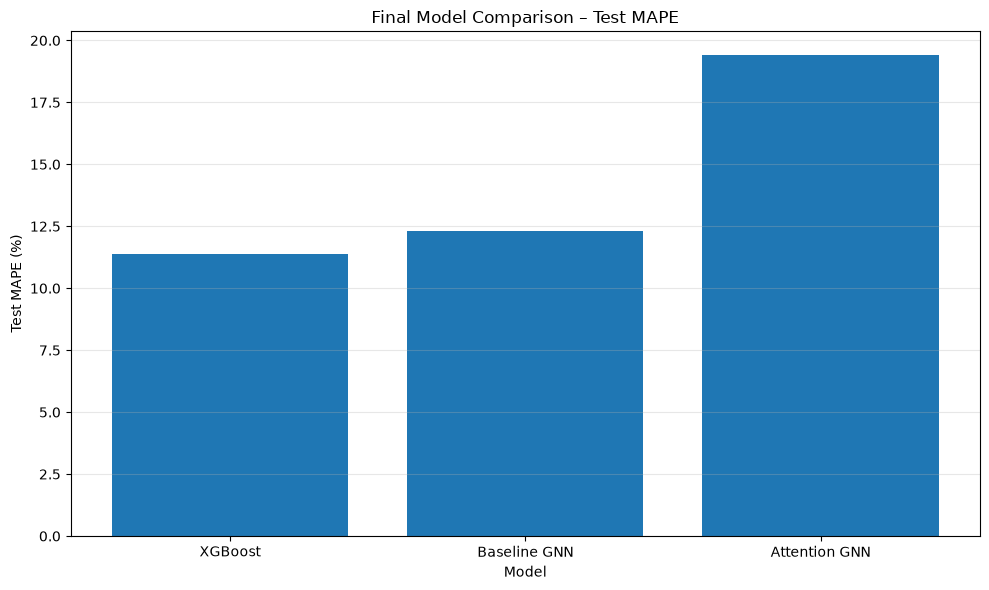

✅ Saved: ..\reports\week-4\visualizations\final_model_mape_comparison.png


In [32]:
mape_plot = (VIS_DIR / "final_model_mape_comparison.png")

plt.figure(figsize=(10, 6))

plt.bar(model_comparison["Model"],model_comparison["MAPE"])

plt.xlabel("Model")
plt.ylabel("Test MAPE (%)")
plt.title("Final Model Comparison – Test MAPE")

plt.grid(axis="y",alpha=0.3)

plt.tight_layout()

plt.savefig(mape_plot,dpi=150,bbox_inches="tight")

plt.show()

print("✅ Saved:",mape_plot)

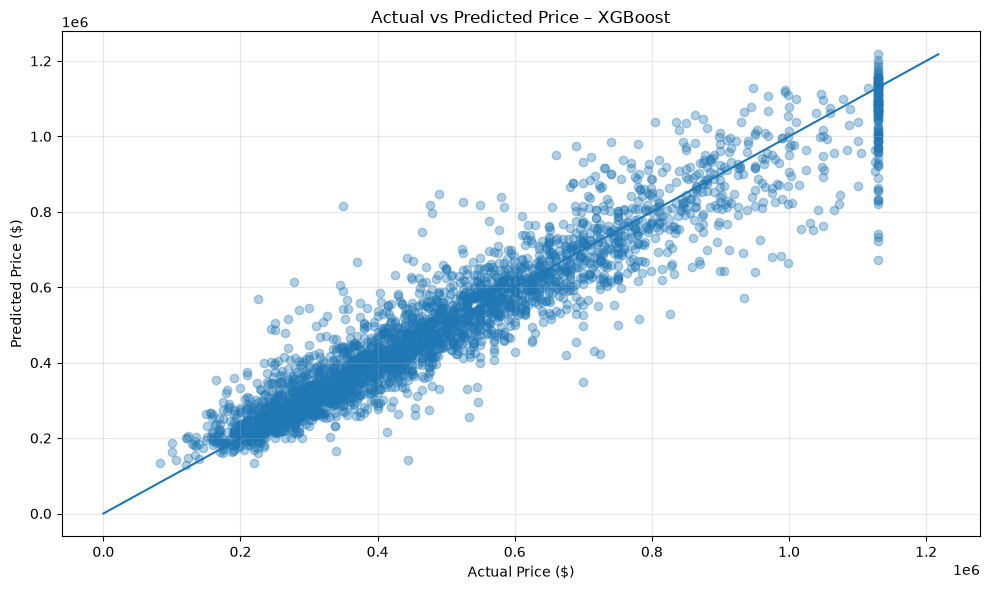

✅ Saved: ..\reports\week-4\visualizations\final_actual_vs_predicted.png


In [33]:
actual_predicted_plot = (VIS_DIR / "final_actual_vs_predicted.png")

if best_model_name == "XGBoost":
    best_prediction_column = ("xgboost_prediction")

elif best_model_name == "Baseline GNN":
    best_prediction_column = ("baseline_gnn_prediction")

else:
    best_prediction_column = ("attention_gnn_prediction")

plt.figure(figsize=(10, 6))

plt.scatter(final_predictions["actual_price"],final_predictions[best_prediction_column],alpha=0.35)

max_price = max(final_predictions["actual_price"].max(),final_predictions[best_prediction_column].max())

plt.plot([0, max_price],[0, max_price])

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title(f"Actual vs Predicted Price – " f"{best_model_name}")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(actual_predicted_plot,dpi=150,bbox_inches="tight")
plt.show()

print("✅ Saved:",actual_predicted_plot)

In [34]:
comparison_xgb_model = (BASE_DIR / "models" / "xgboost_comparison.pkl")

joblib.dump(xgb_model,comparison_xgb_model)

print("✅ Saved:",comparison_xgb_model)

✅ Saved: ..\models\xgboost_comparison.pkl


In [35]:
assert len(final_predictions) == 3242

assert len(model_comparison) == 3

assert set(model_comparison["Model"]) == {"XGBoost","Baseline GNN","Attention GNN"}

assert dashboard_predictions["selected_prediction"].notna().all()

assert np.isfinite(dashboard_predictions["selected_prediction"]).all()

assert os.path.exists(GNN_DIR / "final_model_comparison.csv")

assert os.path.exists(GNN_DIR / "final_prediction_error_analysis.csv")

assert os.path.exists(GNN_DIR / "final_price_range_analysis.csv")

assert os.path.exists(GNN_DIR / "dashboard_predictions.csv")

assert os.path.exists(BASE_DIR / "models" / "xgboost_comparison.pkl")

print("=" * 60)
print("WEEK 4 DAY 4 VALIDATION")
print("=" * 60)

print(f"Test properties: " f"{len(final_predictions):,}")

print(f"Best model: " f"{best_model_name}")

print(f"Best MAPE: " f"{best_model_row['MAPE']:.2f}%")

print(f"Best RMSE: " f"${best_model_row['RMSE']:,.2f}")

print(f"Best R²: " f"{best_model_row['R2']:.4f}")

print("\n✅ All three models evaluated on the same test set.")
print("✅ Prediction error analysis completed.")
print("✅ Price-range analysis completed.")
print("✅ Dashboard-ready predictions created.")
print("✅ Week 4 Day 4 validation passed.")

WEEK 4 DAY 4 VALIDATION
Test properties: 3,242
Best model: XGBoost
Best MAPE: 11.39%
Best RMSE: $75,232.36
Best R²: 0.9038

✅ All three models evaluated on the same test set.
✅ Prediction error analysis completed.
✅ Price-range analysis completed.
✅ Dashboard-ready predictions created.
✅ Week 4 Day 4 validation passed.
